# RT-DETR Inference Results (378px, 60 epochs, no LoRA)
Evaluate the frozen-encoder model (num_queries=100, 6 decoder layers, dim_feedforward=2048) on Oxford Pets.

In [1]:
import sys
from pathlib import Path
import json
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from torchvision.ops import box_iou
from collections import defaultdict

sys.path.insert(0, str(Path.cwd().parent))

DATA_DIR = Path("datasets/oxford_pets")
CKPT_DIR = Path("results/deim_pets_no_lora/checkpoints")

with open(DATA_DIR / "annotations.json") as f:
    meta = json.load(f)
num_classes = len(meta["categories"])
class_names = [c["name"] for c in meta["categories"]]
print(f"Classes: {num_classes}")

Classes: 37


In [2]:
from core.encoders import create_encoder
from core.decoders.rtdetr import RTDETRDecoder
from core.data.dataset import FFTDataset
from core.training.trainer import DecoderLightningModule

encoder = create_encoder("dinov2_vits14", input_size=378)
decoder = RTDETRDecoder(
    encoder,
    num_classes=num_classes,
    num_queries=10,
    num_decoder_layers=6,
    dim_feedforward=2048,
)

ckpt_path = CKPT_DIR / "last-v1.ckpt"
print(f"Checkpoint: {ckpt_path.name}")

lit = DecoderLightningModule.load_from_checkpoint(
    str(ckpt_path), decoder=decoder,
    map_location="cuda" if torch.cuda.is_available() else "cpu",
)
lit.eval()
device = next(lit.parameters()).device
print(f"Device: {device}")

c:\Users\dhruv\.conda\envs\fft\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using cache found in C:\Users\dhruv/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\dhruv/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\dhruv/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\dhruv/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Checkpoint: last-v1.ckpt


c:\Users\dhruv\.conda\envs\fft\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Device: cuda:0


In [3]:
# Load validation split
dataset = FFTDataset.from_folder(DATA_DIR, task="detection", transform=encoder.get_transform())
_, val_dataset = dataset.split(0.2)
print(f"Val size: {len(val_dataset)}")

Val size: 734


In [4]:
def cxcywh_to_xyxy(boxes):
    cx, cy, w, h = boxes.unbind(-1)
    return torch.stack([cx - w/2, cy - h/2, cx + w/2, cy + h/2], dim=-1).clamp(0, 1)

def predict(sample):
    """Run inference on a single sample."""
    img = sample["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        features = lit.decoder.encoder.forward_features(img)
        features["image"] = img
        preds = lit.decoder(features)
    logits = preds["pred_logits"][0]
    boxes = preds["pred_boxes"][0]
    scores, labels = logits.sigmoid().max(-1)
    boxes_xyxy = cxcywh_to_xyxy(boxes)
    return scores.cpu(), labels.cpu(), boxes_xyxy.cpu()

def show_prediction(sample, score_thr=0.05, ax=None):
    """Visualize predictions vs GT."""
    scores, labels, boxes = predict(sample)
    img_tensor = sample["image"]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_display = (img_tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    H, W = img_display.shape[:2]
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img_display)
    # GT boxes (green)
    gt_labels = sample["labels"]
    gt_boxes = sample["boxes"]
    valid = gt_labels >= 0
    for lb, bx in zip(gt_labels[valid], gt_boxes[valid]):
        bx_xyxy = cxcywh_to_xyxy(bx.unsqueeze(0))[0]
        x1, y1, x2, y2 = bx_xyxy * torch.tensor([W, H, W, H])
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-2, f"GT: {class_names[lb]}",
                color='lime', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))
    # Predicted boxes (red)
    mask = scores > score_thr
    pred_scores, pred_labels, pred_boxes = scores[mask], labels[mask], boxes[mask]
    order = pred_scores.argsort(descending=True)
    for idx in order[:5]:
        s = pred_scores[idx].item()
        lb = pred_labels[idx].item()
        bx = pred_boxes[idx]
        x1, y1, x2, y2 = bx * torch.tensor([W, H, W, H])
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
        ax.add_patch(rect)
        ax.text(x2, y1-2, f"{class_names[lb]} {s:.2f}",
                color='red', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7),
                ha='right')
    n_above = mask.sum().item()
    ax.set_title(f"{n_above} preds > {score_thr} | top: {scores.max():.3f}", fontsize=9)
    ax.axis('off')
    return scores, labels, boxes

## 1. Training Curves

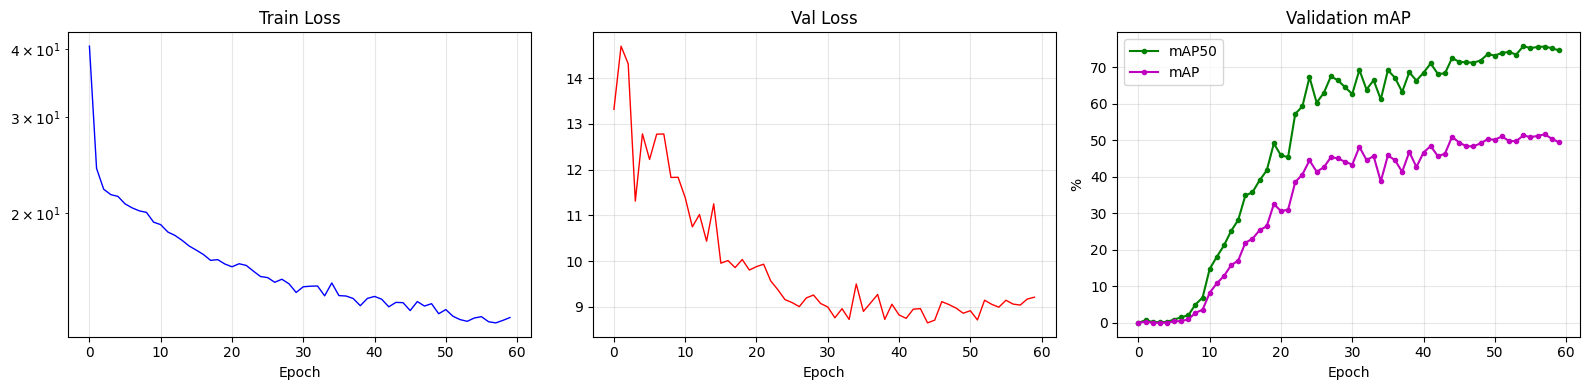

Best val_map50: 75.7% (epoch 54)
Best val_map:   51.6% (epoch 57)


In [5]:
import pandas as pd

metrics = pd.read_csv(CKPT_DIR / "lightning_logs/version_2/metrics.csv")

# Aggregate per epoch
epoch_train = metrics.dropna(subset=["train_loss"]).groupby("epoch")["train_loss"].mean()
epoch_val = metrics.dropna(subset=["val_loss"]).groupby("epoch").first()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epoch_train.index, epoch_train.values, 'b-', linewidth=1)
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epoch_val.index, epoch_val["val_loss"], 'r-', linewidth=1)
axes[1].set_title("Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].grid(True, alpha=0.3)

ax2 = axes[2]
ax2.plot(epoch_val.index, epoch_val["val_map50"] * 100, 'g-o', markersize=3, label="mAP50")
ax2.plot(epoch_val.index, epoch_val["val_map"] * 100, 'm-o', markersize=3, label="mAP")
ax2.set_title("Validation mAP")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("%")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best val_map50: {epoch_val['val_map50'].max()*100:.1f}% (epoch {epoch_val['val_map50'].idxmax()})")
print(f"Best val_map:   {epoch_val['val_map'].max()*100:.1f}% (epoch {epoch_val['val_map'].idxmax()})")

## 2. Prediction Visualizations

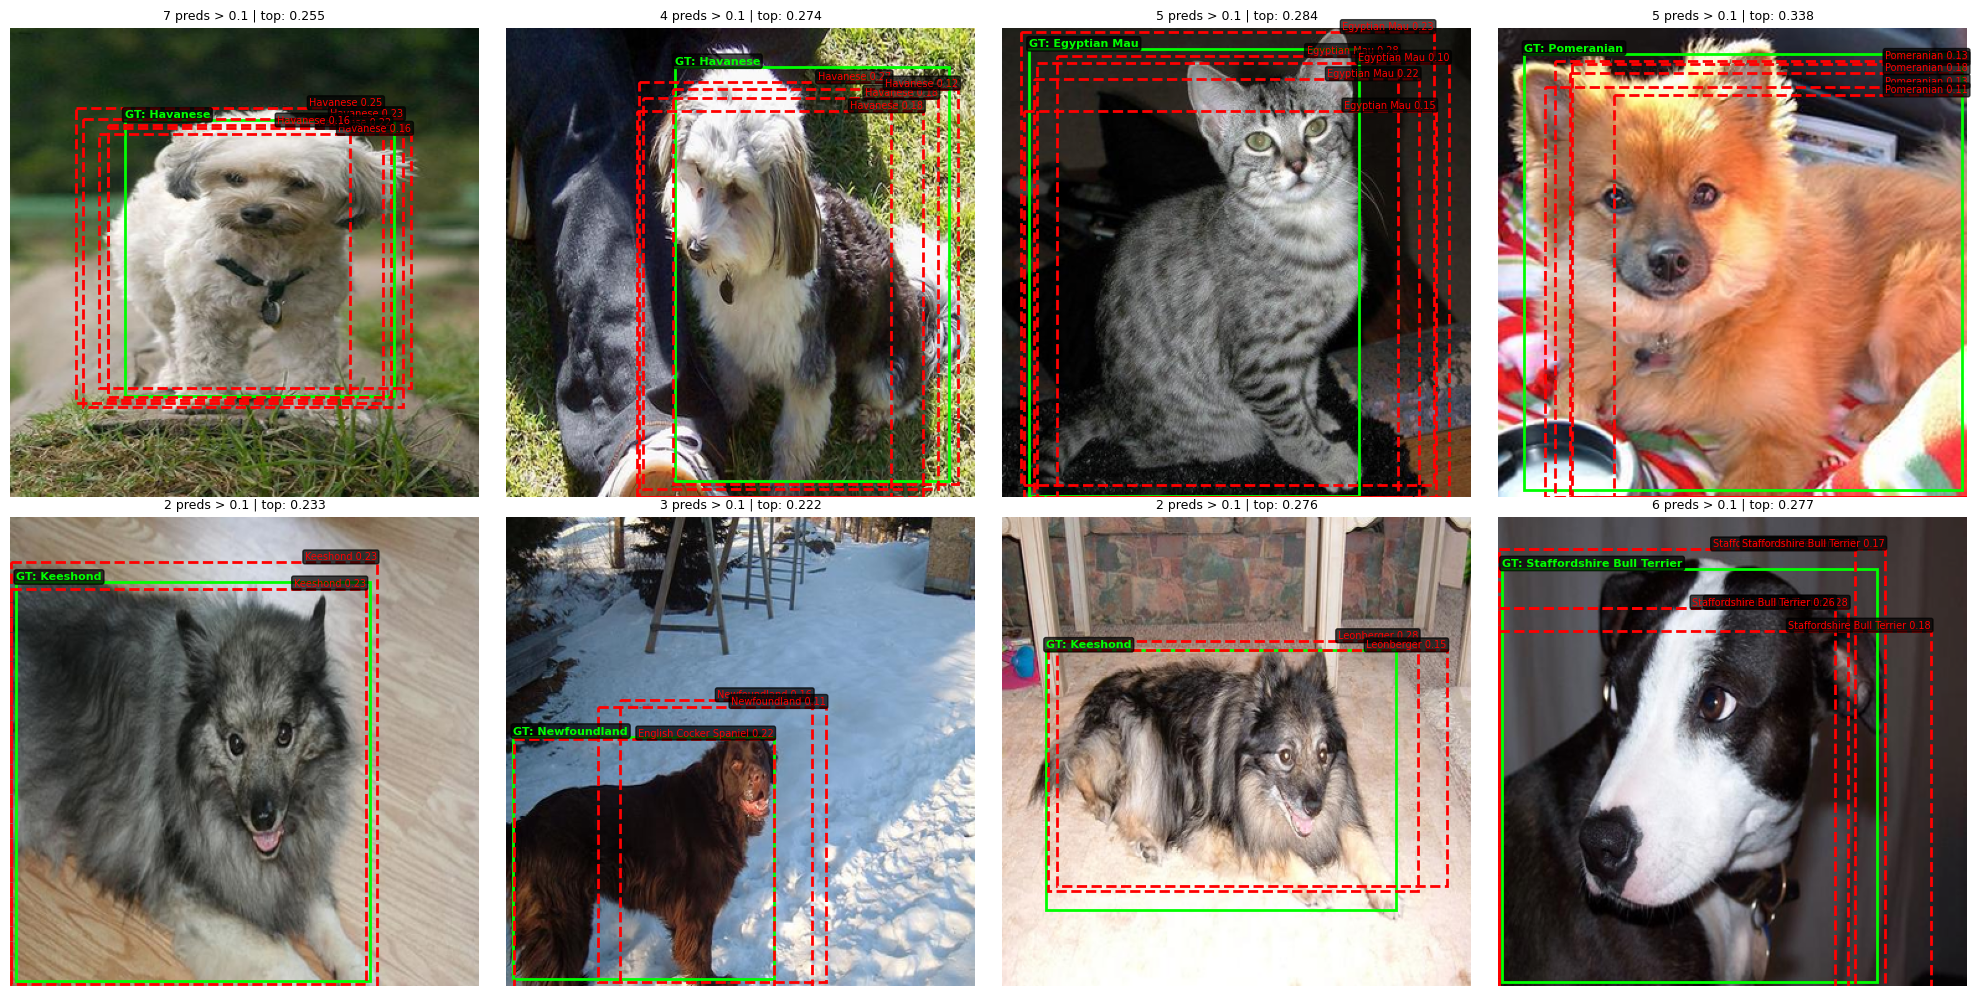

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
rng = np.random.RandomState(42)
indices = rng.choice(len(val_dataset), 8, replace=False)

for ax, idx in zip(axes.flat, indices):
    show_prediction(val_dataset[idx], score_thr=0.1, ax=ax)

plt.tight_layout()
plt.show()

## 3. Score Distribution Analysis

Evaluated 200 images
Top-1 score:  mean=0.2675, median=0.2612, max=0.5424
Top-1 IoU:    mean=0.7598, median=0.7926
Top-1 class correct: 83.5%


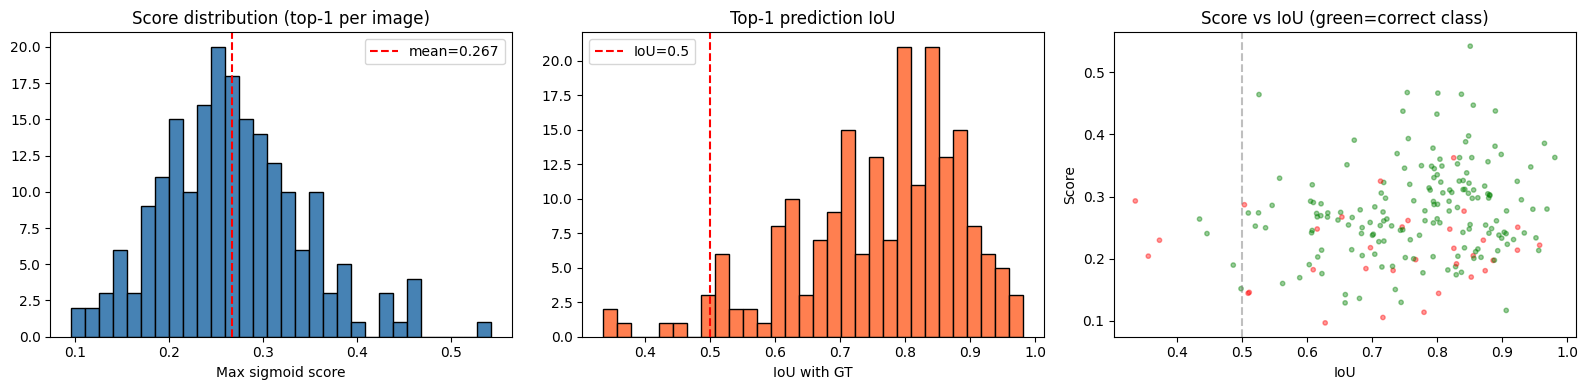

In [7]:
N_EVAL = min(200, len(val_dataset))

all_max_scores = []
all_top1_correct = []
all_top1_iou = []

for i in range(N_EVAL):
    sample = val_dataset[i]
    scores, labels, boxes = predict(sample)
    top_score, top_idx = scores.max(0)
    all_max_scores.append(top_score.item())

    gt_labels = sample["labels"]
    gt_boxes = sample["boxes"]
    valid = gt_labels >= 0
    if valid.any():
        gt_xyxy = cxcywh_to_xyxy(gt_boxes[valid])
        pred_box = boxes[top_idx].unsqueeze(0)
        iou = box_iou(pred_box, gt_xyxy).max().item()
        all_top1_iou.append(iou)
        all_top1_correct.append(int(labels[top_idx].item() == gt_labels[valid][0].item()))

print(f"Evaluated {N_EVAL} images")
print(f"Top-1 score:  mean={np.mean(all_max_scores):.4f}, median={np.median(all_max_scores):.4f}, max={np.max(all_max_scores):.4f}")
print(f"Top-1 IoU:    mean={np.mean(all_top1_iou):.4f}, median={np.median(all_top1_iou):.4f}")
print(f"Top-1 class correct: {np.mean(all_top1_correct)*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(all_max_scores, bins=30, edgecolor='black', color='steelblue')
axes[0].set_xlabel("Max sigmoid score")
axes[0].set_title("Score distribution (top-1 per image)")
axes[0].axvline(np.mean(all_max_scores), color='red', linestyle='--', label=f'mean={np.mean(all_max_scores):.3f}')
axes[0].legend()

axes[1].hist(all_top1_iou, bins=30, edgecolor='black', color='coral')
axes[1].set_xlabel("IoU with GT")
axes[1].set_title("Top-1 prediction IoU")
axes[1].axvline(0.5, color='red', linestyle='--', label='IoU=0.5')
axes[1].legend()

# Score vs IoU scatter
axes[2].scatter(all_top1_iou, all_max_scores[:len(all_top1_iou)], alpha=0.4, s=10, c=['green' if c else 'red' for c in all_top1_correct])
axes[2].set_xlabel("IoU")
axes[2].set_ylabel("Score")
axes[2].set_title("Score vs IoU (green=correct class)")
axes[2].axvline(0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 4. Per-Class Accuracy & IoU

In [8]:
class_correct = defaultdict(int)
class_total = defaultdict(int)
class_ious = defaultdict(list)

for i in range(N_EVAL):
    sample = val_dataset[i]
    scores, labels, boxes = predict(sample)
    gt_labels = sample["labels"]
    gt_boxes = sample["boxes"]
    valid = gt_labels >= 0
    if not valid.any():
        continue
    gt_cls = gt_labels[valid][0].item()
    gt_xyxy = cxcywh_to_xyxy(gt_boxes[valid])
    top_idx = scores.argmax()
    pred_cls = labels[top_idx].item()
    iou = box_iou(boxes[top_idx].unsqueeze(0), gt_xyxy).max().item()
    class_total[gt_cls] += 1
    class_correct[gt_cls] += int(pred_cls == gt_cls)
    class_ious[gt_cls].append(iou)

# Sort by accuracy
cls_ids = sorted(class_total.keys())
accs = [class_correct[c] / class_total[c] * 100 for c in cls_ids]
avg_ious = [np.mean(class_ious[c]) for c in cls_ids]
names = [class_names[c] for c in cls_ids]

print(f"{'Class':<25s} {'Acc':>5s} {'AvgIoU':>7s} {'Count':>5s}")
print("-" * 45)
for c in cls_ids:
    acc = class_correct[c] / class_total[c] * 100
    avg_iou = np.mean(class_ious[c])
    print(f"{class_names[c]:<25s} {acc:>4.0f}% {avg_iou:>6.3f} {class_total[c]:>5d}")

print(f"\nOverall accuracy: {np.mean(accs):.1f}%")
print(f"Overall mean IoU: {np.mean(avg_ious):.3f}")

Class                       Acc  AvgIoU Count
---------------------------------------------
Abyssinian                  78%  0.763     9
American Bulldog            75%  0.725     4
American Pit Bull Terrier   50%  0.721     6
Basset Hound                83%  0.764     6
Beagle                      75%  0.593     4
Bengal                      75%  0.759     8
Birman                      86%  0.771     7
Bombay                     100%  0.847     7
Boxer                       83%  0.769     6
British Shorthair           80%  0.753     5
Chihuahua                   75%  0.772     4
Egyptian Mau               100%  0.658     7
English Cocker Spaniel     100%  0.849     1
English Setter             100%  0.799     4
German Shorthaired         100%  0.798     4
Great Pyrenees             100%  0.610     2
Havanese                    83%  0.691     6
Japanese Chin              100%  0.791     4
Keeshond                    83%  0.824     6
Leonberger                 100%  0.776     3
Maine Co

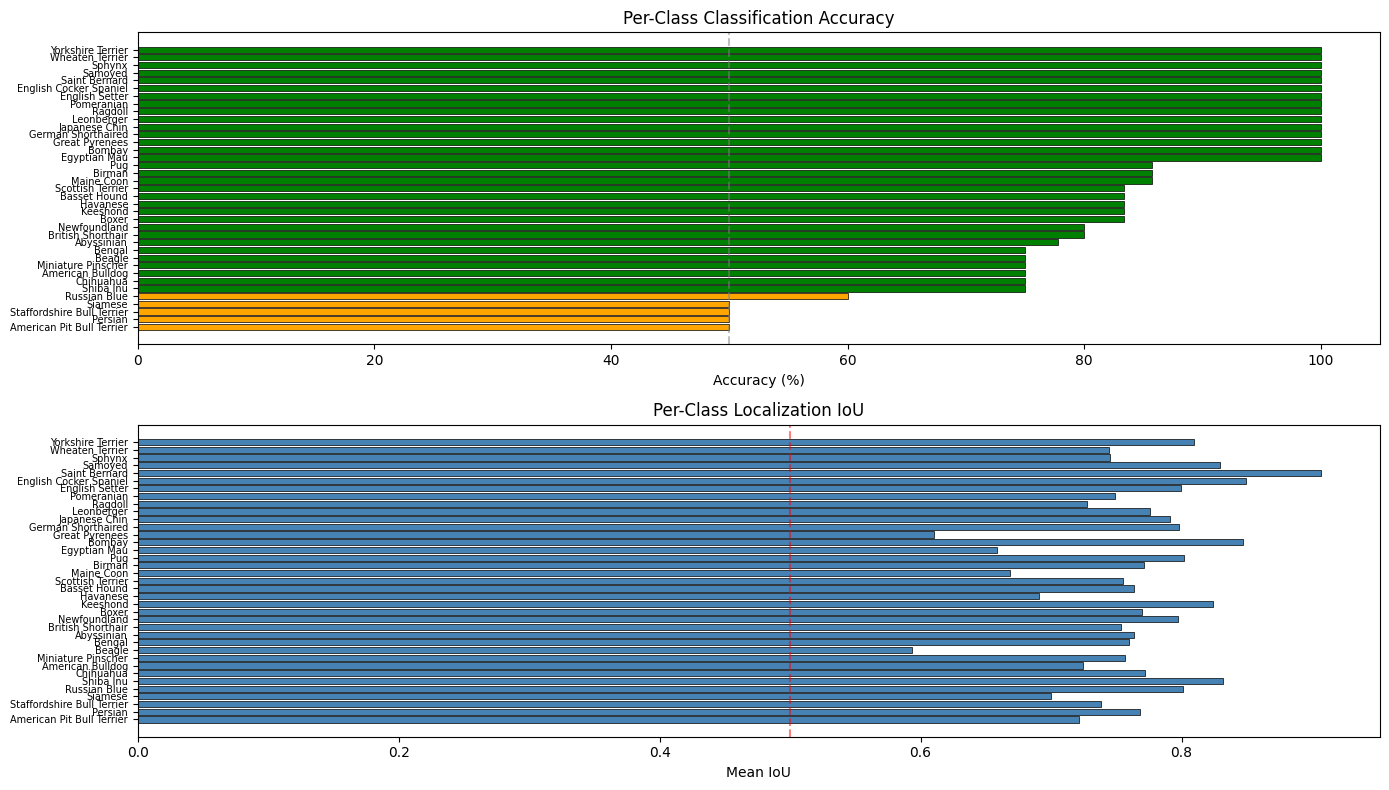

In [9]:
# Bar chart of per-class accuracy
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

sort_idx = np.argsort(accs)[::-1]
sorted_names = [names[i] for i in sort_idx]
sorted_accs = [accs[i] for i in sort_idx]
sorted_ious = [avg_ious[i] for i in sort_idx]

colors = ['green' if a >= 70 else 'orange' if a >= 40 else 'red' for a in sorted_accs]
ax1.barh(range(len(sorted_names)), sorted_accs, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_yticks(range(len(sorted_names)))
ax1.set_yticklabels(sorted_names, fontsize=7)
ax1.set_xlabel("Accuracy (%)")
ax1.set_title("Per-Class Classification Accuracy")
ax1.invert_yaxis()
ax1.axvline(50, color='gray', linestyle='--', alpha=0.5)

ax2.barh(range(len(sorted_names)), sorted_ious, color='steelblue', edgecolor='black', linewidth=0.5)
ax2.set_yticks(range(len(sorted_names)))
ax2.set_yticklabels(sorted_names, fontsize=7)
ax2.set_xlabel("Mean IoU")
ax2.set_title("Per-Class Localization IoU")
ax2.invert_yaxis()
ax2.axvline(0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Confusion: Most Common Misclassifications

In [10]:
confusion = defaultdict(int)

for i in range(N_EVAL):
    sample = val_dataset[i]
    scores, labels, boxes = predict(sample)
    gt_labels = sample["labels"]
    valid = gt_labels >= 0
    if not valid.any():
        continue
    gt_cls = gt_labels[valid][0].item()
    pred_cls = labels[scores.argmax()].item()
    if pred_cls != gt_cls:
        confusion[(class_names[gt_cls], class_names[pred_cls])] += 1

# Top 15 confusions
top_conf = sorted(confusion.items(), key=lambda x: -x[1])[:15]
print(f"{'GT Class':<25s} -> {'Predicted':<25s} {'Count':>5s}")
print("-" * 60)
for (gt, pred), count in top_conf:
    print(f"{gt:<25s} -> {pred:<25s} {count:>5d}")

GT Class                  -> Predicted                 Count
------------------------------------------------------------
Persian                   -> Maine Coon                    3
Siamese                   -> Birman                        2
Bengal                    -> Egyptian Mau                  2
American Pit Bull Terrier -> Staffordshire Bull Terrier     2
Russian Blue              -> British Shorthair             2
Birman                    -> Ragdoll                       1
Shiba Inu                 -> Abyssinian                    1
Abyssinian                -> Siamese                       1
Havanese                  -> Wheaten Terrier               1
Staffordshire Bull Terrier -> Boxer                         1
Basset Hound              -> Beagle                        1
Keeshond                  -> Leonberger                    1
Siamese                   -> Abyssinian                    1
Miniature Pinscher        -> Sphynx                        1
Abyssinian            